In [22]:
from enum import StrEnum

COLORS = dict(
  blue_light = 0xB2CAD4,
  blue_steel = 0x698894,
  blue_navy = 0x264653,
  teal = 0x62C9C9,
  teal_light = 0x73EBEB,
  teal_dark = 0x204141,
  teal_deep = 0x0D3D3D,
  teal_medium = 0x346A6A,
  teal_medium_plus = 0x306363,
  green_light = 0x33BC3C,
  green= 0x4DAA2A,
  green_medium = 0x4CAF50,
  green_medium2 = 0x2A9A31,
  green_dark  = 0x388E3C,
  green_darker  = 0x17561B,
  green_darker_alt = 0x195E1E,
  green_deep  = 0x081C09,
  orange = 0xFF9800,
  copper_light = 0xE89048,
  copper_orange = 0xF4A261,
  copper_red = 0xE76F51,
  copper_dark = 0x6A3210,
  bronze_deep = 0x504D47,
  bronze_dark = 0x5A3A12,
  bronze_light = 0xE0B060,
  bronze_gold = 0xE9C46A,
  yellow = 0xFFEB3B,
  parchment_light = 0xFCF5E5,
  parchment = 0xF4EDDE,
  parchment_medium = 0xD2CCBF,
  parchment_dark = 0xB0ABA0,
  parchment_deep = 0x8E8A81,
  purple_light = 0x8A4A9A,
  purple = 0x7B2D8E,
  purple_medium = 0x572064,
  purple_dark = 0x2A0A3A,
  red_light = 0xF44336,
  red = 0xC1121F,
  red_medium  = 0xB71C1C,
  red_dark = 0x981515,
  red_darker = 0x6F0F0F,
  red_deep = 0x4D0B0B,
  red_deeper = 0x3A0808,
)

class ColorFormat(StrEnum):
  HASH = '#'
  HEX = '0x'
  FLOAT = '0.0-1.0'
  RGBA = 'RGBA'


RGBA = ['red', 'green', 'blue', 'alpha']

# Returns an RGBA color string as int (0-255) or float (0.0-1.0)
#  hex_clr is an RGBA color in hex string :
def rgba_color(hex_clr:str, normalize:bool=True) -> list[float] | list[int]:
  rgba:list[str] = hex_clr[2:4], hex_clr[4:6], hex_clr[6:8], hex_clr[8:10]
  for n, v in enumerate(rgba[0:2]):
      assert len(v) > 0, f"Value for {RGBA[n]} should be a hex string"

  print(f"Converting {rgba} from {hex_clr}")
  colors:list[int] = [int(c, 16) for c in rgba if c]
  print(f'RGBing itj: {colors}')
  return [float(c)/255.0 for c in colors] if normalize else colors

HexColorType = str | list[float] | list[int]
def hex_color(name:str, format:ColorFormat=ColorFormat.HASH, force_alpha:float=0.0) -> HexColorType:
    if name not in COLORS: raise ValueError(f"{name} not found in COLORS; should be one of: {sorted(COLORS.keys())}")
    clr:str = hex(COLORS[name])
    if force_alpha and len(clr)==6:
      clr = f"{clr}{round(force_alpha * 255.0, 0)}"
      print(f"updated hex color: {clr}")
    
    res:HexColorType
    is_float: bool = format==ColorFormat.FLOAT

    if format==ColorFormat.RGBA or is_float:
      res = rgba_color(clr, is_float)
    elif format==ColorFormat.HASH:
      res = clr.replace('0x', ColorFormat.HASH.value)
    else:
      res = clr

    return res

In [54]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import numpy
# Optional: set a font list with emoji support
from matplotlib.font_manager import FontProperties
from numpy import ndarray, float32

# Graph extents (from -1.0 to +1.0)
# graph_range:list[float] = [-1.0, +1.0]
# graph_xy:list[float] = [-1.0, +1.0, -1.0, +1.0]
graph_xy:ndarray = np.array([-1.0, +1.0, -1.0, +1.0], dtype=float32)
graph_range:ndarray= np.array([-1.0, +1.0], dtype=float32)

print(graph_xy.dtype)
print(graph_range.dtype)
print('-' * 40)
print(type(graph_xy))
print(type(graph_range))

# Arrows, colors, styles ↑
arrow_rt:str='⟶'

# Colors
color_x = hex_color('purple')
color_y = hex_color('teal_dark')
color_teal = hex_color('teal_dark')
color_green = hex_color('green_medium')
color_bronze = hex_color('bronze_gold')
color_copper = hex_color('copper_light')

# Props
arrow_props:dict[str, any] = dict(arrowstyle='<-')

# Gradient def
nw = hex_color('blue_light', ColorFormat.FLOAT)
ne = hex_color('green_light', ColorFormat.FLOAT)
sw = hex_color('bronze_gold', ColorFormat.FLOAT)
se = hex_color('yellow', ColorFormat.FLOAT)
quad_colors:list[str] = [nw, ne, sw, se]    
print(f"quad_colors: {quad_colors}")

float32
float32
----------------------------------------
<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
Converting ('b2', 'ca', 'd4', '') from 0xb2cad4
RGBing itj: [178, 202, 212]
Converting ('33', 'bc', '3c', '') from 0x33bc3c
RGBing itj: [51, 188, 60]
Converting ('e9', 'c4', '6a', '') from 0xe9c46a
RGBing itj: [233, 196, 106]
Converting ('ff', 'eb', '3b', '') from 0xffeb3b
RGBing itj: [255, 235, 59]
quad_colors: [[0.6980392156862745, 0.792156862745098, 0.8313725490196079], [0.2, 0.7372549019607844, 0.23529411764705882], [0.9137254901960784, 0.7686274509803922, 0.41568627450980394], [1.0, 0.9215686274509803, 0.23137254901960785]]


Plotting with limits [-1.  1.] and extent [-1.  1. -1.  1.] and colors: [[0.6980392156862745, 0.792156862745098, 0.8313725490196079], [0.2, 0.7372549019607844, 0.23529411764705882], [0.9137254901960784, 0.7686274509803922, 0.41568627450980394], [1.0, 0.9215686274509803, 0.23137254901960785]]


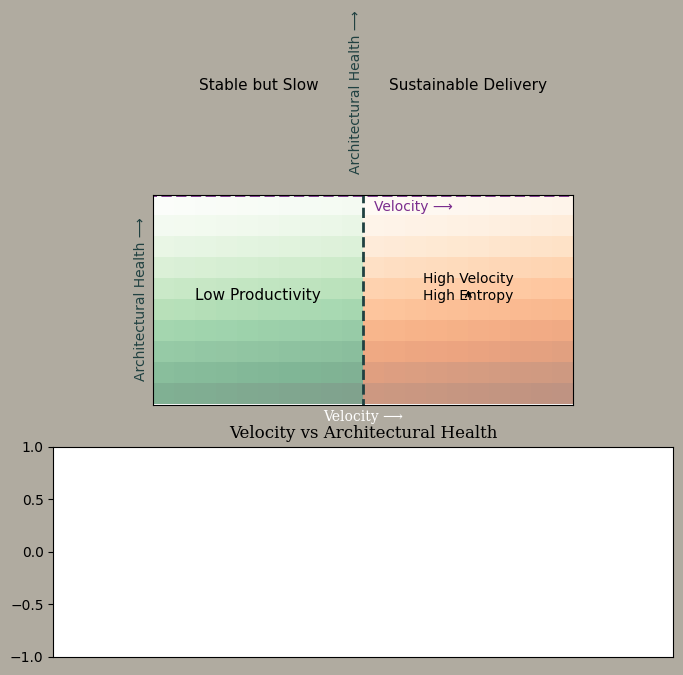

In [55]:
fig, (ax, ax2) = plt.subplots(
    2, 1, 
    edgecolor=hex_color('parchment_deep'),
    facecolor=hex_color('parchment_dark'),
    figsize=(8,6),
    sharex='all',
)



# plt.color = hex_color('teal_medium_plus'),
plt.xlim(graph_range)
plt.ylim(graph_range)


# data = np.array([[2, 1],[3, 4]])

print(f"Plotting with limits {graph_range} and extent {graph_xy} and colors: {quad_colors}")

# Q1: Top-Right (Positive X, Positive Y) - Green Gradient
q1 = np.linspace(0, 1, 100).reshape(10, 10)
# Q2: Top-Left (Negative X, Positive Y) - Blue Gradient
q2 = np.linspace(0, 1, 100).reshape(10, 10)
# Q3: Bottom-Left (Negative X, Negative Y) -  Red Gradient
q3 = np.linspace(0, 1, 100).reshape(10, 10)
# Q4: Bottom-Right (Positive X, Negative Y) - Yellow Gradient
q4 = np.linspace(0, 1, 100).reshape(10, 10)


ax.imshow(q2[::-1], cmap='Blues', extent=[-1, 0, 0, 1], alpha=0.5, origin='lower')
ax.imshow(q1[::-1], cmap='Reds', extent=[0, 1, 0, 1], alpha=0.5, origin='lower')
ax.imshow(q3[::-1], cmap='Greens', extent=[-1, 0, -1, 0], alpha=0.5, origin='lower')
ax.imshow(q4[::-1], cmap='Oranges', extent=[0, 1, -1, 0], alpha=0.5, origin='lower')

# ax.xlim(graph_range)
# ax.ylim(graph_range)


# ax.imshow(quad_colors, extent=extent, origin='lower', cmap='RdYlBu', interpolation='bilinear')

# Color Quadrants NW:(x<0, y>0), NE:(x<0, y>0), NW:(x<0, y<0), SW:(x<0, y<0)
# ax.axvspan(-1.0, 0, ymin=0.0, ymax=1.0, color='lightcyan', alpha=0.5, zorder=-1)
# ax.axvspan(0, 1.0, ymin=0.0, ymax=1.0, color='honeydew', alpha=0.5, zorder=-1) # ymin/ymax scaled 0-1
# ax.axvspan(-1.0, 0, ymin=-1.0, ymax=0.0, color='lavender', alpha=0.5, zorder=-1)
# ax.axvspan(0, 1.0, ymin=-1.0, ymax=0.0, color='mistyrose', alpha=0.5, zorder=-1)

ax.axhline(color=color_x, linewidth=2, linestyle='dashed', xmin=-1, xmax=1)
ax.axvline(color=color_y, linewidth=2, linestyle='dashed', ymin=-1, ymax=1)

# No ticks
ax.set_xticks([])
ax.set_yticks([])


# quadrant labels
## Top
ax.text(-0.5, 0.5, "Stable but Slow", fontsize=11, horizontalalignment='center')
ax.text(0.5, 0.5, "Sustainable Delivery", fontsize=11, horizontalalignment='center')
ax.text(-0.5, -0.5, "Low Productivity", fontsize=11, horizontalalignment='center')
ax.annotate("High Velocity\nHigh Entropy", xy=(0.5,-0.5), ha='center', arrowprops=arrow_props) # Velocity ↑\nArchitecture ↓

# ax.annotate("High Velocity\nHigh Entropy", xy=(0.0,-0.0), xytext=(0.5,-0.5), ha='center', arrowprops=ap) # Velocity ↑\nArchitecture ↓
# ax.annotate(xy=(0.4, -0.4), arrowprops=arrowprops, ha='right')
# axis labels
velocity_lbl:str = f"Velocity {arrow_rt}"
health_lbl:str = f"Architectural Health {arrow_rt}"
ax.set_xlabel(velocity_lbl, c="white", fontfamily=["serif"])
ax.set_ylabel(health_lbl, c=color_y)
ax.text(0.05, -0.025, velocity_lbl, c=color_x, ha='left', va='top')
ax.text(0, 0.10, health_lbl, c=color_y, ha='right', rotation='vertical', va='bottom',)
# ax.annotate("Velocity ↑\nArchitecture ↓", xy=(0.0,-0.0), xytext=(0.0,0.00), arrowprops=dict(arrowstyle="->"), ha='right')

# red_col:str = hex_color("red")
# arrow_stl:str = dict(arrowstyle="->")
# ax.plot([0.0, 0.5], [0.0, -0.5], linestyle="dashed", color=red_col)

plt.title("Velocity vs Architectural Health", fontfamily=["serif", "Cursive", "Fantasy"])
plt.show()

In [ ]:


emoji_font:FontProperties = FontProperties(fname="Symbola.ttf")



# for f in fm.findSystemFonts():
#     print(f"{f} *Emoji" if "Emoji" in f else f)

plt.rcParams['font.family'] = []

    # 'DejaVu Sans',          # normal text
    # 'Segoe UI Emoji',       # Windows emoji
    # 'Noto Color Emoji'      # Linux emoji
# ]



In [ ]:

fig, ax = plt.subplots(figsize=(11,8))


# Draw axis lines
ax.axhline(0, linewidth=2)
ax.axvline(0, linewidth=2)

# Quadrant shading
ax.fill_between([-1,0],0,1,alpha=0.08)
ax.fill_between([0,1],0,1,alpha=0.08)
ax.fill_between([-1,0],-1,0,alpha=0.08)
ax.fill_between([0,1],-1,0,alpha=0.08)

# Quadrant labels
ax.text(-0.85,0.75,"Stable but Slow",fontsize=12)
ax.text(0.15,0.75,"Sustainable Delivery",fontsize=12)

ax.text(-0.85,-0.75,"Low Productivity",fontsize=12)
ax.text(0.15,-0.75,"🔥 High Velocity\nHigh Entropy",fontproperties=emoji_font)

# Trajectory illustrating velocity increasing while architecture declines
x = [-0.7,-0.3,0.2,0.6]
y = [0.5,0.2,-0.2,-0.6]

ax.plot(x,y,marker='o',linewidth=2)

# Arrow showing direction
ax.annotate(
    "",
    xy=(0.6,-0.6),
    xytext=(-0.7,0.5),
    arrowprops=dict(arrowstyle="->",linewidth=2)
)

# Axis labels
ax.set_xlabel("Velocity (Ticket Throughput)",fontsize=14)
ax.set_ylabel("Architectural Health",fontsize=14)

ax.set_title("Velocity vs Architectural Health",fontsize=18)

# Clean axes
ax.set_xticks([])
ax.set_yticks([])

ax.set_xlim(-1,1)
ax.set_ylim(-1,1)

# plt.tight_layout()

# Export
# res = plt.savefig("./velocity_architecture_phase_diagram.png",dpi=300)

plt.show()